# Capítulo 2: Modelos poblacionales

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/01-poblaciones.ipynb)

Notebook que acompaña al Capítulo 2 de *Introducción al Modelado Continuo*. Reproduce todas las figuras del capítulo y permite cambiar los parámetros de cada modelo. Cada figura de las notas sale de una celda marcada con su nombre de archivo.

Las herramientas que se usan son sólo las del capítulo: signo de las derivadas, nulclinas, cantidades conservadas y simulación numérica. No se linealiza nada (eso llega en el Capítulo 5 y en el notebook `03-lineales-HG`).

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from imc import estilo, fases
from imc.estilo import COLORES

estilo.activar()
plt.close(plt.figure())   # inicializa el backend inline fuera de los rc_context de abajo (si no, las figuras no se muestran)
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/

def fuente(F):
    # contexto con fuente F: las figuras se incluyen chicas en las notas y la letra tiene que seguir legible
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})

def agrandar(ax, flecha=20, marcador=10):
    # flechas de sentido y marcadores de equilibrio más grandes, por el mismo motivo
    for t in ax.texts:
        if getattr(t, "arrow_patch", None) is not None:
            t.arrow_patch.set_mutation_scale(flecha)
    for l in ax.lines:
        if l.get_marker() == "o":
            l.set_markersize(marcador)

## 2.1 Primeros modelos: Malthus y logística

Tasa de crecimiento logística $\alpha(P) = a(1-P/K)$ y comparación de las dos soluciones. La logística adimensionalizada es $\dot p = a(1-p)p$; midiendo el tiempo en unidades de $1/a$ desaparece también $a$.

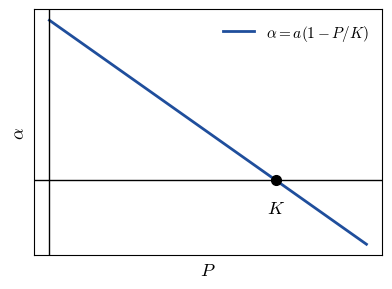

In [2]:
a, K = 1.0, 1.0
P = np.linspace(0, 1.4 * K, 200)

with fuente(13):
    fig, ax = plt.subplots(figsize=(4.5, 3.2))
    ax.plot(P, a * (1 - P / K), color=COLORES["traj"], label=r"$\alpha = a(1-P/K)$")
    ax.axhline(0, color="black", lw=1); ax.axvline(0, color="black", lw=1)
    ax.plot(K, 0, "ko", ms=7); ax.text(K, -0.12, "$K$", ha="center", va="top")
    ax.set_xlabel("$P$"); ax.set_ylabel(r"$\alpha$"); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="upper right")
    if GUARDAR: estilo.guardar(fig, "tasa-logistica")

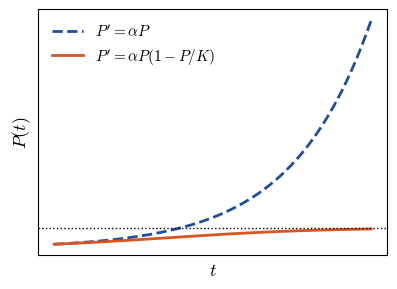

In [3]:
t = np.linspace(0, 4, 200)
P0, alpha = 0.2, 1.0
with fuente(13):
    fig, ax = plt.subplots(figsize=(4.5, 3.2))
    ax.plot(t, P0 * np.exp(alpha * t), "--", label=r"$P' = \alpha P$")
    ax.plot(t, K / (1 + (K - P0) / P0 * np.exp(-alpha * t)), label=r"$P' = \alpha P(1-P/K)$")
    ax.axhline(K, color="black", ls=":", lw=1)
    ax.set_xlabel("$t$"); ax.set_ylabel("$P(t)$"); ax.set_xticks([]); ax.set_yticks([]); ax.legend()
    if GUARDAR: estilo.guardar(fig, "maltus-vs-logistico")

### La recta de fase

Para una ecuación escalar $\dot p = f(p)$ alcanza con el signo de $f$: los ceros son equilibrios, entre dos ceros consecutivos la solución es monótona. Los puntos llenos son equilibrios estables, los vacíos inestables.

*(Figura pendiente del texto: recta de fase de la logística.)*

equilibrios: [2.6342404362350863e-16, 1.0]


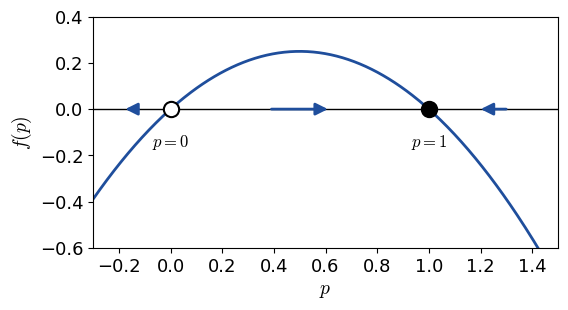

In [4]:
f = lambda p: (1 - p) * p      # logística adimensional, a = 1
with fuente(14):
    fig, ax = plt.subplots(figsize=(6, 3))
    eq = fases.recta_de_fase(f, -0.3, 1.5, ax=ax, nombre="p")
    ax.set_ylim(-0.6, 0.4); agrandar(ax, flecha=22, marcador=11)
    for e in eq:
        ax.text(e, -0.1, rf"$p = {round(e, 6):g}$", ha="center", va="top", fontsize=12)
    print("equilibrios:", eq)
    if GUARDAR: estilo.guardar(fig, "recta-fase-logistica")

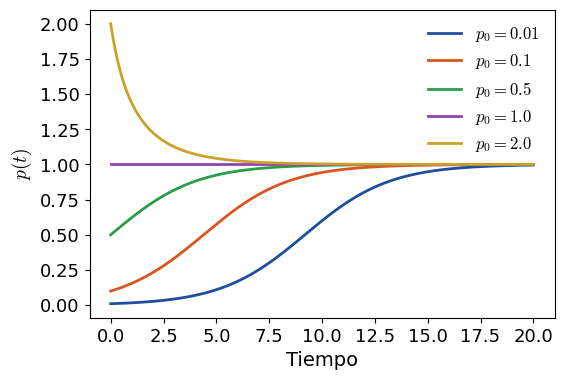

In [5]:
# Soluciones para varias condiciones iniciales (Figura 'logistica')
with fuente(14):
    fig, ax = plt.subplots()
    t = np.linspace(0, 20, 400)
    for p0 in [0.01, 0.1, 0.5, 1.0, 2.0]:
        ax.plot(t, 1 / (1 + (1 - p0) / p0 * np.exp(-0.5 * t)), label=f"$p_0 = {p0}$")
    ax.set_xlabel("Tiempo"); ax.set_ylabel("$p(t)$"); ax.legend()
    if GUARDAR: estilo.guardar(fig, "logistica")

## 2.2 Lotka–Volterra clásico

$$h' = \rho\,h(1-p),\qquad p' = -\tfrac{1}{\rho}\,p(1-h).$$

Nulclinas: $h=0$, $p=1$ (de $h'=0$) y $p=0$, $h=1$ (de $p'=0$). La cantidad $\mathcal H(h,p) = (h-\ln h)+\rho^2(p-\ln p)$ se conserva: las trayectorias son sus curvas de nivel.

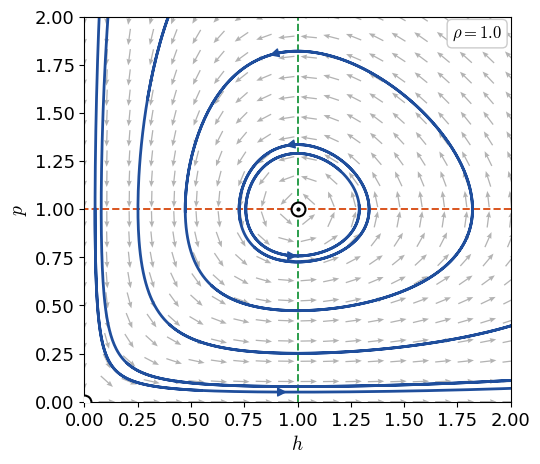

In [6]:
def LV1(t, X, rho):
    h, p = X
    return [rho * h * (1 - p), -p * (1 - h) / rho]

rho = 1.0
H = lambda h, p: (h - np.log(h)) + rho**2 * (p - np.log(p))

with fuente(14):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    inicios = [(0.2, 0.2), (0.4, 0.4), (0.6, 0.6), (0.8, 0.8), (1.2, 1.2), (0.05, 1.0)]
    fases.retrato(LV1, (0, 2), (0, 2), inicios, T=12, ax=ax, args=(rho,),
                  nulclinas=[(lambda X, Y: 1 - Y, COLORES["nul_h"]), (lambda X, Y: 1 - X, COLORES["nul_p"])],
                  equilibrios=[(1, 1, "centro"), (0, 0, "silla")], xlabel="$h$", ylabel="$p$")
    agrandar(ax)
    estilo.parametros(ax, rf"$\rho = {rho}$", fontsize=12)
    if GUARDAR: estilo.guardar(fig, "LV1")

H max - H min a lo largo de la trayectoria: 2.173466295829485e-09


Text(0.5, 1.0, 'Oscilaciones periódicas de presas y predadores')

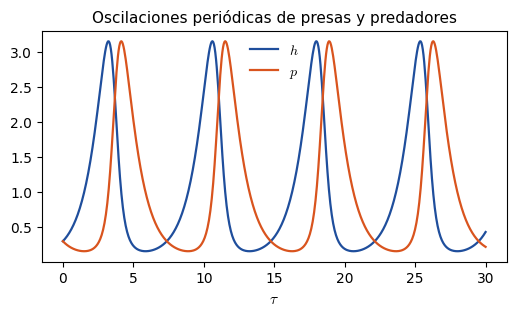

In [7]:
# Verificación numérica de la conservación de H a lo largo de una trayectoria
sol = solve_ivp(LV1, (0, 30), [0.3, 0.3], args=(rho,), rtol=1e-10, atol=1e-12, dense_output=True)
tt = np.linspace(0, 30, 600); h, p = sol.sol(tt)
print("H max - H min a lo largo de la trayectoria:", np.ptp(H(h, p)))
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(tt, h, label="$h$"); ax.plot(tt, p, label="$p$")
ax.set_xlabel(r"$\tau$"); ax.legend(); ax.set_title("Oscilaciones periódicas de presas y predadores")

## 2.3 Lotka–Volterra con capacidad de carga

$$h' = \rho\,h\Bigl(1-\frac{h}{k}-p\Bigr),\qquad p' = -\tfrac{1}{\rho}\,p(1-h).$$

La nulclina de $h$ pasa a ser la recta $p = 1-h/k$. Tres casos según $k$; para $k>1$ el acercamiento al equilibrio de coexistencia $(1,1-1/k)$ es monótono o en espiral según el signo de $\rho^2 - 4k(k-1)$; por ahora lo vemos en la simulación, cuando desarrollemos más la teoría vamos a poder explicarlo.

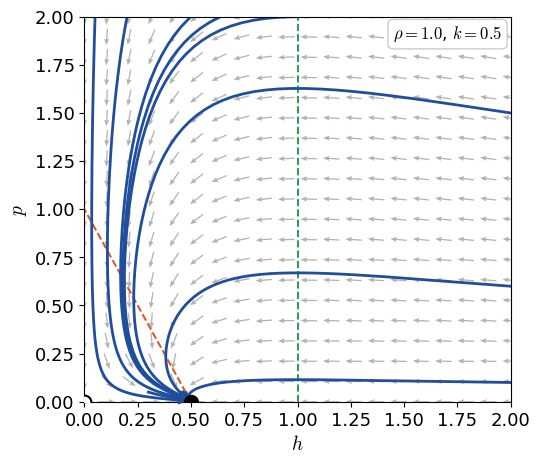

In [8]:
def LV2(t, X, rho, k):
    h, p = X
    return [rho * h * (1 - h / k - p), -p * (1 - h) / rho]

def figura_LV2(rho, k, nombre, T=25):
    with fuente(14):
        fig, ax = plt.subplots(figsize=(5.5, 5))
        inicios = [(0.05, 2.0), (0.2, 2.0), (0.5, 2.0), (1.0, 2.0), (1.6, 2.0), (2.0, 1.5), (2.0, 0.6), (2.0, 0.1), (0.3, 0.05)]
        eqs = [(0, 0, "silla"), (k, 0, "estable" if k <= 1 else "silla")]
        if k > 1:
            eqs.append((1, 1 - 1 / k, "estable"))
        fases.retrato(LV2, (0, 2), (0, 2), inicios, T=T, ax=ax, args=(rho, k),
                      nulclinas=[(lambda X, Y: 1 - X / k - Y, COLORES["nul_h"]), (lambda X, Y: 1 - X, COLORES["nul_p"])],
                      equilibrios=eqs, xlabel="$h$", ylabel="$p$")
        agrandar(ax)
        estilo.parametros(ax, rf"$\rho = {rho}$, $k = {k}$", fontsize=12)
        if GUARDAR: estilo.guardar(fig, nombre)
    return fig

figura_LV2(1.0, 0.5, "LVk<1");

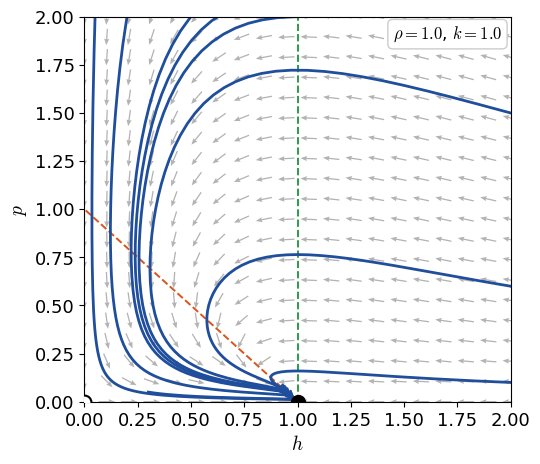

In [9]:
figura_LV2(1.0, 1.0, "LVk=1", T=60);

rho^2 - 4k(k-1) = 2.4399999999999995


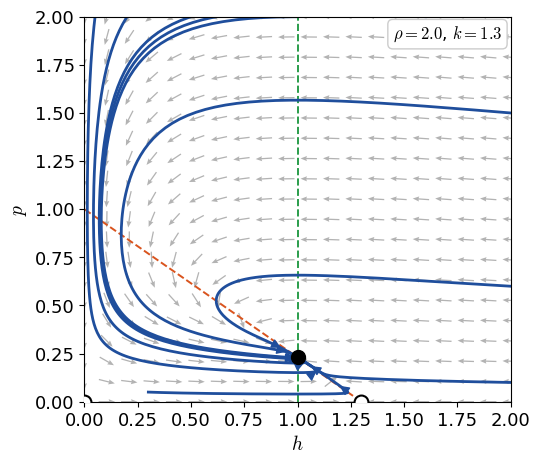

In [10]:
# k > 1, acercamiento monótono: rho^2 >= 4k(k-1)
rho, k = 2.0, 1.3
print("rho^2 - 4k(k-1) =", rho**2 - 4 * k * (k - 1))
figura_LV2(rho, k, "LVk>1-1");

rho^2 - 4k(k-1) = -7.0


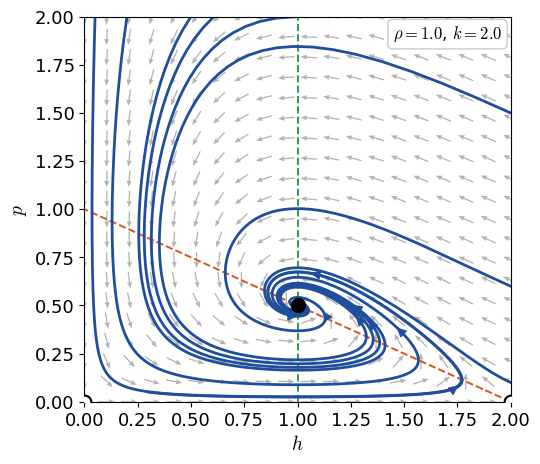

In [11]:
# k > 1, acercamiento oscilatorio: rho^2 < 4k(k-1)
rho, k = 1.0, 2.0
print("rho^2 - 4k(k-1) =", rho**2 - 4 * k * (k - 1))
figura_LV2(rho, k, "LVk>1-2");

### Mapa de los casos en el plano $(k,\rho)$

La curva $\rho^2 = 4k(k-1)$ separa nodo (acercamiento monótono) de foco (oscilatorio). Es un buen ejercicio elegir un punto de cada región y comprobarlo con `figura_LV2`.

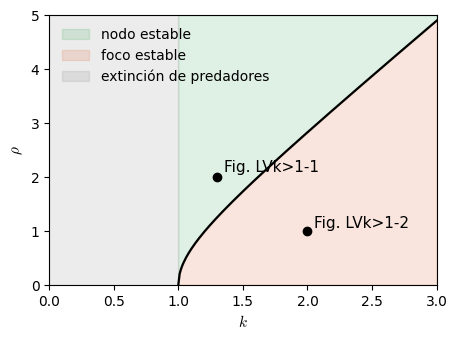

In [12]:
fig, ax = plt.subplots(figsize=(5, 3.5))
kk = np.linspace(1, 3, 200)
ax.plot(kk, 2 * np.sqrt(kk * (kk - 1)), color="black")
ax.fill_between(kk, 2 * np.sqrt(kk * (kk - 1)), 5, alpha=0.15, color=COLORES["nul_p"], label="nodo estable")
ax.fill_between(kk, 0, 2 * np.sqrt(kk * (kk - 1)), alpha=0.15, color=COLORES["nul_h"], label="foco estable")
ax.axvspan(0, 1, alpha=0.15, color="0.5", label="extinción de predadores")
ax.plot([1.3, 2.0], [2.0, 1.0], "ko"); ax.text(1.35, 2.1, "Fig. LVk>1-1"); ax.text(2.05, 1.05, "Fig. LVk>1-2")
ax.set_xlim(0, 3); ax.set_ylim(0, 5); ax.set_xlabel("$k$"); ax.set_ylabel(r"$\rho$"); ax.legend(loc="upper left")

## 2.4 Ciclos límite: el modelo de bacterias

$$h' = h\Bigl(1-\frac{h}{k}\Bigr) - \frac{\alpha_h\,p\,h}{\beta+h},\qquad p' = \frac{\alpha_p\,p\,h}{\beta+h} - \gamma p,$$
con $\alpha_h = (1-1/k)(\beta+1)$ y $\alpha_p = \gamma(\beta+1)$, de modo que $(1,1)$ es el equilibrio no trivial. La nulclina de $h$ es la parábola $p = (\beta+h)(1-h/k)/\alpha_h$, con vértice en $h=(k-\beta)/2$. Las simulaciones sugieren el umbral $k_c = 2+\beta$.

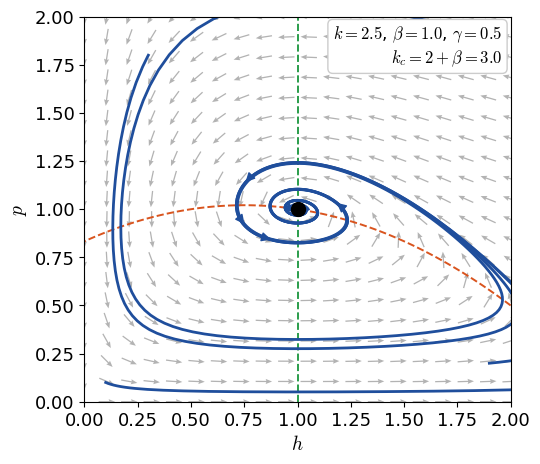

In [13]:
def bacterias(t, X, k, beta, gamma):
    h, p = X
    ah = (1 - 1 / k) * (beta + 1)
    ap = gamma * (beta + 1)
    return [h * (1 - h / k) - ah * p * h / (beta + h), ap * p * h / (beta + h) - gamma * p]

def figura_bacterias(k, beta, gamma, nombre, T=80):
    ah = (1 - 1 / k) * (beta + 1)
    with fuente(14):
        fig, ax = plt.subplots(figsize=(5.5, 5))
        inicios = [(1.05, 1.0), (0.3, 1.8), (1.9, 0.2), (0.1, 0.1), (1.9, 1.9)]
        fases.retrato(bacterias, (0, 2), (0, 2), inicios, T=T, ax=ax, args=(k, beta, gamma),
                      nulclinas=[(lambda X, Y: (beta + X) * (1 - X / k) / ah - Y, COLORES["nul_h"]), (lambda X, Y: 1 - X, COLORES["nul_p"])],
                      equilibrios=[(1, 1, "estable" if k < 2 + beta else "inestable")], xlabel="$h$", ylabel="$p$")
        agrandar(ax)
        estilo.parametros(ax, rf"$k = {k}$, $\beta = {beta}$, $\gamma = {gamma}$" + "\n" + rf"$k_c = 2+\beta = {2 + beta}$", fontsize=12)
        if GUARDAR: estilo.guardar(fig, nombre)
    return fig

beta, gamma = 1.0, 0.5
figura_bacterias(2.5, beta, gamma, "bacteria1");

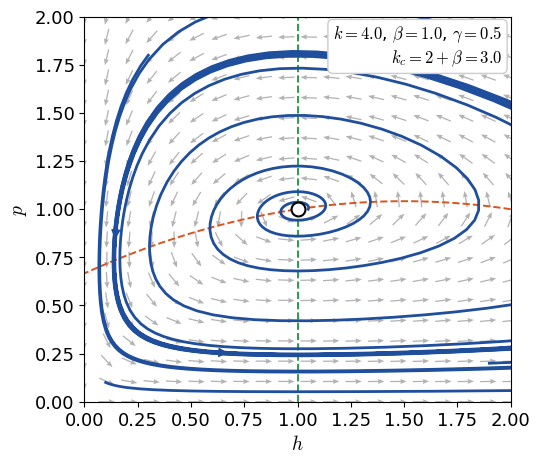

In [14]:
figura_bacterias(4.0, beta, gamma, "bacteria2", T=150);

Text(3.05, 3.9976693892004382, '$k_c = 2+\\beta$')

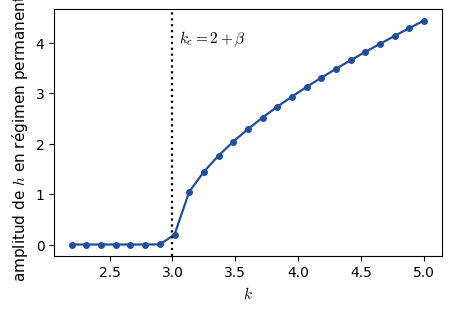

In [15]:
# Amplitud de la oscilación de h en régimen permanente, en función de k:
# el ciclo aparece en k_c y su amplitud crece con k (esto es lo que el Capítulo 8 llama bifurcación de Hopf)
ks = np.linspace(2.2, 5.0, 25)
amp = []
for k in ks:
    sol = solve_ivp(bacterias, (0, 600), [1.05, 1.0], args=(k, beta, gamma), rtol=1e-8, max_step=0.5)
    h = sol.y[0][sol.t > 400]
    amp.append(h.max() - h.min())
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(ks, amp, "o-", ms=4); ax.axvline(2 + beta, color="black", ls=":")
ax.set_xlabel("$k$"); ax.set_ylabel("amplitud de $h$ en régimen permanente")
ax.text(2 + beta + 0.05, max(amp) * 0.9, r"$k_c = 2+\beta$")

## 2.5 El modelo SIR

$$\dot s = -\beta s i,\qquad \dot i = \beta s i - \gamma i,\qquad \dot r = \gamma i,\qquad R_0 = \beta/\gamma.$$

Series temporales (figura `SIR`), plano de fases $(s,i)$ con la cantidad conservada $i + s - \frac{1}{R_0}\ln s$ (figura pendiente), pico $i_{\max}$ y tamaño final $s_\infty = s_0 e^{-R_0(1-s_\infty)}$.

pico: i_max = 0.344 en t = 11.2;  s_inf = 0.008


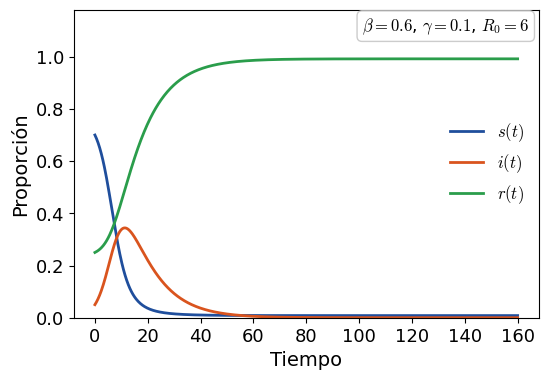

In [16]:
def SIR(t, X, beta, gamma):
    s, i = X
    return [-beta * s * i, beta * s * i - gamma * i]

beta, gamma = 0.6, 0.1
s0, i0 = 0.7, 0.05
sol = solve_ivp(SIR, (0, 160), [s0, i0], args=(beta, gamma), rtol=1e-8, dense_output=True)
t = np.linspace(0, 160, 800); s, i = sol.sol(t); r = 1 - s - i
with fuente(14):
    fig, ax = plt.subplots()
    ax.plot(t, s, label="$s(t)$"); ax.plot(t, i, label="$i(t)$"); ax.plot(t, r, label="$r(t)$")
    ax.set_xlabel("Tiempo"); ax.set_ylabel("Proporción"); ax.set_ylim(0, 1.18); ax.legend(loc="center right")
    estilo.parametros(ax, rf"$\beta={beta}$, $\gamma={gamma}$, $R_0={beta/gamma:.0f}$", loc="upper right", fontsize=12)
    if GUARDAR: estilo.guardar(fig, "SIR")
print(f"pico: i_max = {i.max():.3f} en t = {t[i.argmax()]:.1f};  s_inf = {s[-1]:.3f}")

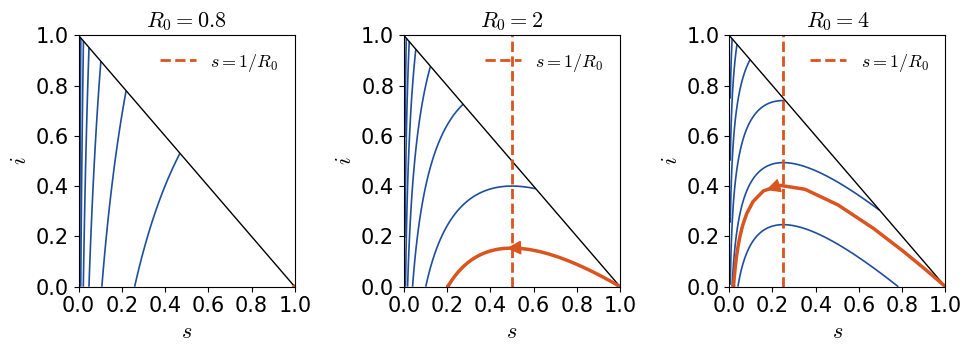

In [17]:
# Plano de fases (s, i): curvas de nivel de i + s - ln(s)/R0 en el triángulo s + i <= 1
def plano_si(R0, ax, niveles=8):
    s = np.linspace(0.005, 1, 400); i = np.linspace(0, 1, 400)
    S, I = np.meshgrid(s, i)
    C = I + S - np.log(S) / R0
    C[S + I > 1] = np.nan
    cs = ax.contour(S, I, C, levels=np.linspace(np.nanmin(C), np.nanmax(C), niveles), colors=[COLORES["traj"]], linewidths=1.2)
    ax.plot([0, 1], [1, 0], color="black", lw=1)
    ax.axvline(1 / R0, color=COLORES["nul_h"], ls="--", label=r"$s = 1/R_0$")
    # una trayectoria con flecha desde (1, 0+)
    solp = solve_ivp(SIR, (0, 200), [0.999, 0.001], args=(R0, 1.0), rtol=1e-9, dense_output=True)
    tt = np.linspace(0, 200, 800); sp, ip = solp.sol(tt)
    ax.plot(sp, ip, color=COLORES["modelo"], lw=2.5)
    k = np.argmax(ip)
    if k > 0:   # si R0 < 1 no hay pico: la trayectoria es un segmento minúsculo y la flecha no aporta
        ax.annotate("", xy=(sp[k + 1], ip[k + 1]), xytext=(sp[k], ip[k]), arrowprops=dict(arrowstyle="-|>", color=COLORES["modelo"], mutation_scale=22))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel("$s$"); ax.set_ylabel("$i$")
    ax.set_title(rf"$R_0 = {R0:g}$"); ax.legend(loc="upper right", fontsize=13)

with fuente(16):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3.8))
    for ax, R0 in zip(axs, [0.8, 2.0, 4.0]):
        plano_si(R0, ax)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "SIR-plano-si")

R0 = 1.5: i_max = 0.063, s_inf = 0.417
R0 = 2: i_max = 0.153, s_inf = 0.203
R0 = 3: i_max = 0.300, s_inf = 0.060


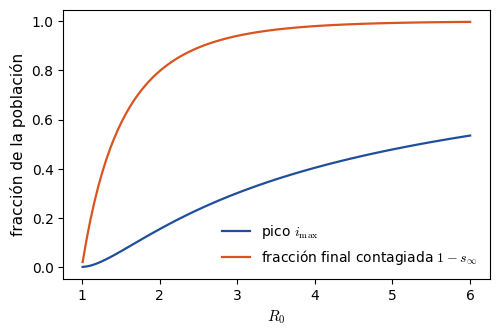

In [18]:
# Pico y tamaño final en función de R0 (con s0 -> 1, i0 -> 0)
R0s = np.linspace(1.01, 6, 100)
imax = 1 - (1 + np.log(R0s)) / R0s
sinf = np.array([brentq(lambda s, R: s - np.exp(-R * (1 - s)), 1e-9, 1 - 1e-9, args=(R,)) for R in R0s])
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(R0s, imax, label=r"pico $i_{\max}$")
ax.plot(R0s, 1 - sinf, label=r"fracción final contagiada $1-s_\infty$")
ax.set_xlabel("$R_0$"); ax.set_ylabel("fracción de la población"); ax.legend()
for R in [1.5, 2, 3]:
    print(f"R0 = {R}: i_max = {1 - (1 + np.log(R)) / R:.3f}, s_inf = {brentq(lambda s: s - np.exp(-R * (1 - s)), 1e-9, 1 - 1e-9):.3f}")

## Para experimentar

1. En `figura_LV2`, elegí un par $(\rho,k)$ de cada región del mapa y verificá el tipo de acercamiento.
2. En `bacterias`, cambiá $\beta$ y comprobá que el umbral se mueve a $2+\beta$.
3. En el SIR, agregá vacunación: $s_0 = 1-v$. ¿Para qué $v$ desaparece el pico? Compará con $1-1/R_0$.
4. Modificá el SIR para incluir nacimientos y muertes (Sección 8.6 de las notas) y buscá el equilibrio endémico.